# 05 — Inferencia de Postura (Stance) en Datos Scrapeados

Aplica los modelos S1 (`twitter-roberta-base` fine-tuneado por tópico) sobre las campañas
donde cada tópico tiene relevancia política directa:

| Campaña | Tópico stance | Justificación |
|---|---|---|
| `trump_2016` | `hillary` | Postura hacia Hillary Clinton — eje central de la campaña |
| `trump_2024` | `abortion` | Dobbs (2022) hizo del aborto el tema central de 2024 |
| `trump_2024` | `feminist` | Candidatura Kamala Harris, debate género |
| `trump_2024` | `climate` | Trump anunció salida del Acuerdo de París y desmantelamiento EPA |
| `españa_2023` | `feminist` | Ley del Sí es Sí, movimiento feminista en campaña |
| `españa_2023` | `abortion` | Derechos reproductivos en agenda política española |
| `españa_2023` | `climate` | Sequías históricas, agenda verde PSOE/Sumar vs negacionismo Vox |
| `brexit_2016` | `climate` | Política medioambiental post-Brexit, salida del marco europeo |

**Prerequisito**: haber ejecutado `04_stance_tweeteval.ipynb` (modelos guardados en GCS).

In [1]:
import sys, os
IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IN_COLAB:
    import subprocess
    subprocess.run(['pip', 'install', '-q',
        'transformers', 'datasets', 'torch', 'google-cloud-storage',
        'pyarrow', 'matplotlib', 'seaborn'], check=True)
    SA = '/content/service-account.json'
    assert os.path.exists(SA), 'Sube service-account.json a /content/'
else:
    SA = '/Users/jimenamillamoreno/Desktop/TFM/TFM/scrapper/service-account.json'

print('Setup OK')

Setup OK


In [ ]:
import io, json, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from google.cloud import storage
from google.oauth2 import service_account

device = 0 if torch.cuda.is_available() else -1
print(f'Device: {"cuda" if device == 0 else "cpu"}')

os.makedirs('figures', exist_ok=True)

_creds = service_account.Credentials.from_service_account_file(SA)
_gcli  = storage.Client(credentials=_creds)

PROCESSED_BUCKET = 'tfm-twitter-processed'
CURATED_BUCKET   = 'tfm-twitter-curated'

STANCE_ID2LABEL = {0: 'none', 1: 'against', 2: 'favor'}
STANCE_COLORS   = {'none': '#95a5a6', 'against': '#e74c3c', 'favor': '#2ecc71'}

CAMPAIGN_TOPICS = {
    'trump_2016':  ['hillary'],
    'trump_2024':  ['abortion', 'feminist', 'climate'],
    'españa_2023': ['feminist', 'abortion', 'climate'],
    'brexit_2016': ['climate'],
}

KEY_EVENTS = {
    'brexit_2016': [
        ('2016-05-16', 'Informe HM Treasury'),
        ('2016-06-16', 'Asesinato Jo Cox'),
        ('2016-06-23', 'Referéndum'),
        ('2016-06-24', 'Leave gana'),
    ],
    'trump_2016': [
        ('2016-09-26', '1er debate'),
        ('2016-10-07', 'Access Hollywood'),
        ('2016-10-09', '2o debate'),
        ('2016-10-28', 'Carta Comey'),
        ('2016-11-08', 'Elecciones'),
        ('2016-11-09', 'Trump gana'),
    ],
    'trump_2024': [
        ('2024-09-10', 'Debate Trump-Harris'),
        ('2024-09-15', '2o intento asesinato\n(Ryan Routh)'),
        ('2024-10-01', 'Debate VP\nWalz vs Vance'),
        ('2024-10-05', 'Huracán Milton'),
        ('2024-11-05', 'Elecciones'),
        ('2024-11-06', 'Trump gana'),
    ],
    'españa_2023': [
        ('2023-07-07', 'Inicio oficial campaña'),
        ('2023-07-10', 'Debate Feijóo-Sánchez'),
        ('2023-07-21', 'Fin de campaña'),
        ('2023-07-22', 'Jornada de reflexión'),
        ('2023-07-23', 'Elecciones 23J'),
        ('2023-07-24', 'PP gana sin mayoría'),
    ],
}

print('Imports OK')

## 1. Carga de datos procesados

In [3]:
dfs = {}
for campaign in CAMPAIGN_TOPICS:
    buf = io.BytesIO(_gcli.bucket(PROCESSED_BUCKET).blob(f'scraped/{campaign}.parquet').download_as_bytes())
    df  = pd.read_parquet(buf)
    df['created_at'] = pd.to_datetime(df['created_at'], utc=True)
    df['date']       = df['created_at'].dt.date
    dfs[campaign]    = df
    print(f'{campaign}: {len(df):,} tweets')

# Cargar también resultados de sentimiento (del notebook 03) si existen
sentiment_results = {}
for campaign in CAMPAIGN_TOPICS:
    blob = _gcli.bucket(CURATED_BUCKET).blob(f'results/sentiment_scraped/{campaign}.parquet')
    if blob.exists():
        buf  = io.BytesIO(blob.download_as_bytes())
        sentiment_results[campaign] = pd.read_parquet(buf)
        print(f'  Sentimiento cargado para {campaign}: {len(sentiment_results[campaign])} rows')
    else:
        print(f'  ⚠ No hay resultados de sentimiento para {campaign} — ejecutar primero 03_sentiment_scraped.ipynb')

trump_2016: 27,776 tweets
trump_2024: 33,957 tweets
españa_2023: 36,383 tweets
brexit_2016: 15,046 tweets
  Sentimiento cargado para trump_2016: 27776 rows
  Sentimiento cargado para trump_2024: 33957 rows
  Sentimiento cargado para españa_2023: 36383 rows
  Sentimiento cargado para brexit_2016: 15046 rows


## 2. Carga de modelos S1 desde GCS

Descarga los checkpoints de `gs://tfm-twitter-curated/models/stance/{topic}/` al disco local.

In [4]:
def download_stance_model(topic, local_dir='/content/models/stance'):
    """Descarga modelo S1 de GCS si no existe ya localmente."""
    dst = Path(local_dir) / topic
    if dst.exists() and any(dst.iterdir()):
        print(f'  {topic}: ya en disco')
        return str(dst)
    dst.mkdir(parents=True, exist_ok=True)
    blobs = list(_gcli.bucket(CURATED_BUCKET).list_blobs(prefix=f'models/stance/{topic}/'))
    if not blobs:
        print(f'  {topic}: ⚠ NO encontrado en GCS')
        return None
    for blob in blobs:
        fname = blob.name.split('/')[-1]
        blob.download_to_filename(str(dst / fname))
    print(f'  {topic}: descargado ({len(blobs)} archivos) → {dst}')
    return str(dst)

# Tópicos únicos necesarios
needed_topics = set(t for topics in CAMPAIGN_TOPICS.values() for t in topics)
print(f'Tópicos necesarios: {needed_topics}')

stance_model_dirs = {}
for topic in needed_topics:
    path = download_stance_model(topic)
    if path:
        stance_model_dirs[topic] = path

print(f'\nModelos disponibles: {list(stance_model_dirs.keys())}')

Tópicos necesarios: {'climate', 'hillary', 'feminist', 'abortion'}
  climate: descargado (7 archivos) → /content/models/stance/climate
  hillary: descargado (5 archivos) → /content/models/stance/hillary
  feminist: descargado (5 archivos) → /content/models/stance/feminist
  abortion: descargado (5 archivos) → /content/models/stance/abortion

Modelos disponibles: ['climate', 'hillary', 'feminist', 'abortion']


In [5]:
# Construcción de pipelines de inferencia por tópico
stance_pipes = {}
for topic, model_dir in stance_model_dirs.items():
    tok   = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    pipe  = pipeline(
        'text-classification',
        model=model, tokenizer=tok,
        device=device,
        truncation=True, max_length=128, batch_size=64,
    )
    stance_pipes[topic] = pipe
    print(f'Pipeline {topic}: listo')

# Mapeo de etiquetas: el modelo usa LABEL_0/1/2
# (entrenado con id2label={0:"none", 1:"against", 2:"favor"})
def map_stance_label(label_str):
    mapping = {'LABEL_0': 'none', 'LABEL_1': 'against', 'LABEL_2': 'favor',
               'none': 'none', 'against': 'against', 'favor': 'favor'}
    return mapping.get(label_str, label_str)

[transformers] emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Pipeline climate: listo


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Pipeline hillary: listo


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Pipeline feminist: listo


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Pipeline abortion: listo


## 3. Inferencia de postura por campaña y tópico

In [6]:
stance_results = {}  # {campaign: {topic: df_with_stance}}

for campaign, topics in CAMPAIGN_TOPICS.items():
    df = dfs[campaign]
    stance_results[campaign] = {}
    print(f'\n{campaign} ({len(df):,} tweets):')

    for topic in topics:
        if topic not in stance_pipes:
            print(f'  {topic}: modelo no disponible — skip')
            continue

        print(f'  Inferencia stance/{topic}...')
        texts   = df['text_clean'].fillna('').tolist()
        results = stance_pipes[topic](texts)

        df_res = df.copy()
        df_res['stance']       = [map_stance_label(r['label']) for r in results]
        df_res['stance_score'] = [r['score'] for r in results]
        df_res['topic']        = topic

        dist = df_res['stance'].value_counts().to_dict()
        print(f'    {dist}')
        stance_results[campaign][topic] = df_res

print('\nInferencia completada.')


trump_2016 (27,776 tweets):
  Inferencia stance/hillary...
    {'against': 17526, 'none': 7116, 'favor': 3134}

trump_2024 (33,957 tweets):
  Inferencia stance/abortion...
    {'none': 32785, 'against': 891, 'favor': 281}
  Inferencia stance/feminist...
    {'none': 31621, 'against': 1441, 'favor': 895}
  Inferencia stance/climate...
    {'none': 33957}

españa_2023 (36,383 tweets):
  Inferencia stance/feminist...
    {'none': 36030, 'against': 313, 'favor': 40}
  Inferencia stance/abortion...
    {'none': 36328, 'against': 54, 'favor': 1}
  Inferencia stance/climate...
    {'none': 36383}

brexit_2016 (15,046 tweets):
  Inferencia stance/climate...
    {'none': 15046}

Inferencia completada.


In [7]:
# Guardar en GCS
for campaign, topics_dict in stance_results.items():
    for topic, df_res in topics_dict.items():
        cols = ['id', 'text', 'text_clean', 'created_at', 'date', 'campaign',
                'like_count', 'retweet_count', 'stance', 'stance_score', 'topic']
        save_cols = [c for c in cols if c in df_res.columns]
        buf = io.BytesIO()
        df_res[save_cols].to_parquet(buf, index=False)
        buf.seek(0)
        path = f'results/stance_scraped/{campaign}_{topic}.parquet'
        _gcli.bucket(CURATED_BUCKET).blob(path).upload_from_file(buf, content_type='application/octet-stream')
        print(f'Guardado: gs://{CURATED_BUCKET}/{path}')

Guardado: gs://tfm-twitter-curated/results/stance_scraped/trump_2016_hillary.parquet
Guardado: gs://tfm-twitter-curated/results/stance_scraped/trump_2024_abortion.parquet
Guardado: gs://tfm-twitter-curated/results/stance_scraped/trump_2024_feminist.parquet
Guardado: gs://tfm-twitter-curated/results/stance_scraped/trump_2024_climate.parquet
Guardado: gs://tfm-twitter-curated/results/stance_scraped/españa_2023_feminist.parquet
Guardado: gs://tfm-twitter-curated/results/stance_scraped/españa_2023_abortion.parquet
Guardado: gs://tfm-twitter-curated/results/stance_scraped/españa_2023_climate.parquet
Guardado: gs://tfm-twitter-curated/results/stance_scraped/brexit_2016_climate.parquet


## 4. Trump 2016 × Hillary Clinton

¿Cómo evolucionó la postura hacia Hillary entre los tweeteros de la campaña Trump?

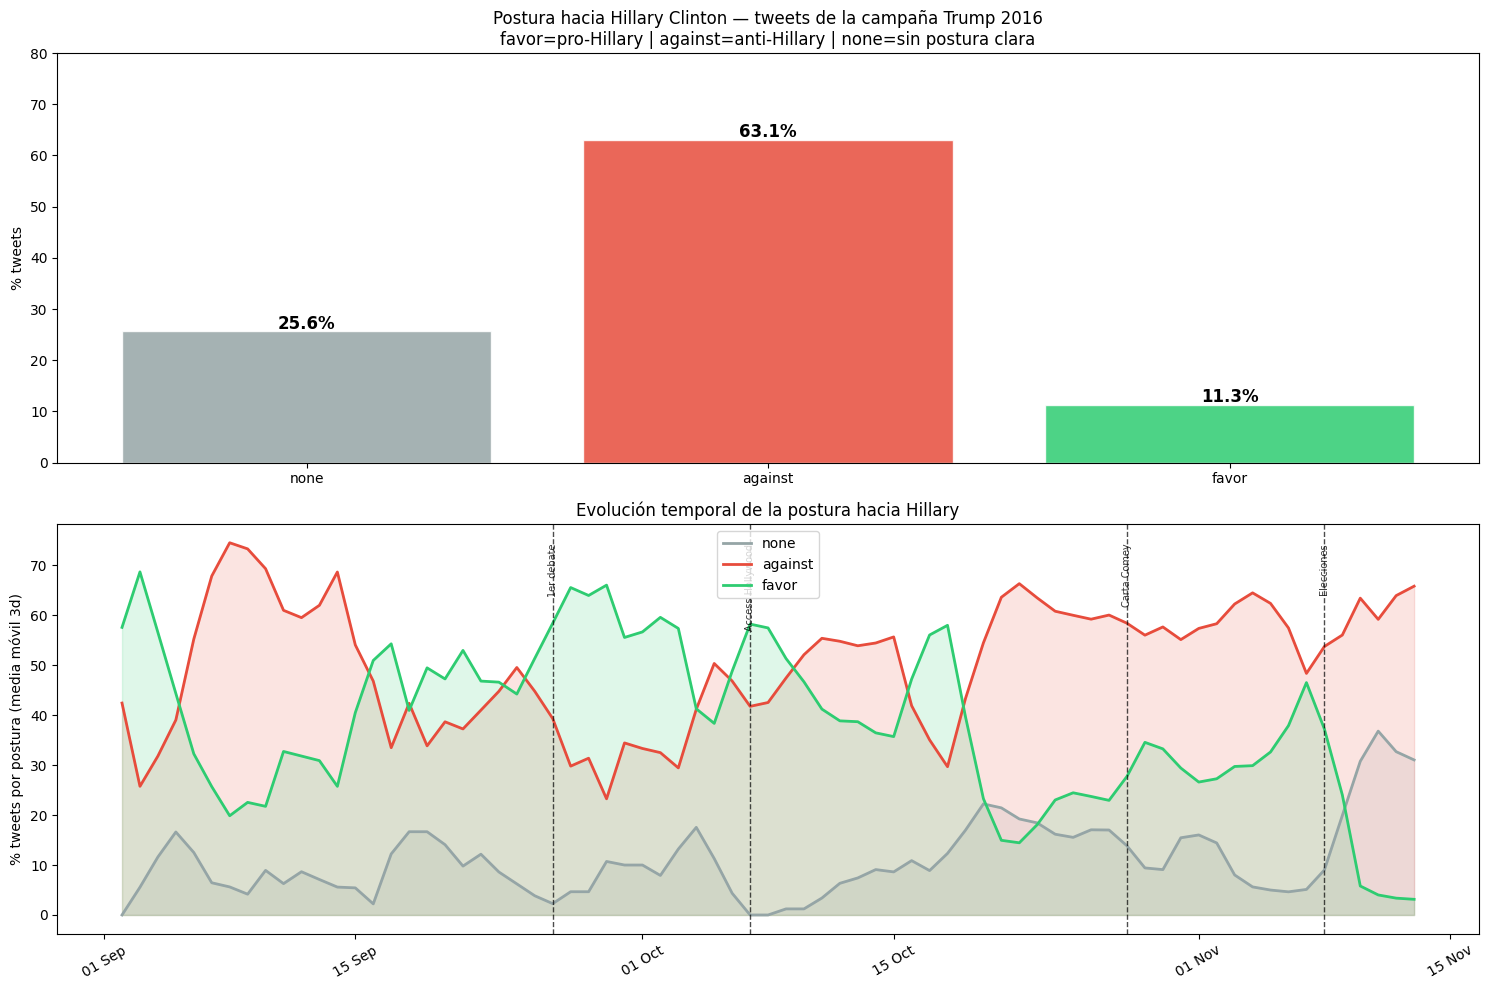


Ejemplos de tweets FAVOR a Hillary:
  [conf=0.98] @OMAHAGEMGIRL @deejay90192  I feel the same! My Daughter lives in safer better world w/ #HillaryForPresident  TY Pioneer Women Trailblazers
  [conf=0.98] Don't let #HillaryForPresident's fight be 4 nada. Support inspiring stories helpin yng womn bcome the leaders of tmr https://t.co/jonpWyrgin
  [conf=0.98] Final countdown! GOTV weekend and Team Hillary and Democrats throughout the country are crushing it! Making History!!!!

Ejemplos de tweets AGAINST Hillary:
  [conf=0.98] Wouldn't want 2B #CrookedHillary or in the #ClintonCrimeCartel Cause #Crooked &amp; Co. R really  #DeepInTheSwamp #MAGA @realDonaldTrump #tcot https://t.co/GGgO
  [conf=0.98] Can't the Clintons be on time for ANYTHING? #copolitics #MakingUsWait #NeverHillary #NotMyPresident #StillWithHer #leftyfail https://t.co/dInjVcFVPC
  [conf=0.98] We can call hillary a Two Time Loser. #tcot #voted #NeverHillary @RealJamesWoods @TheRReport @Glockfan19 @RBNetwork1 @Chief1787 @jo

In [8]:
if 'hillary' in stance_results.get('trump_2016', {}):
    df_h = stance_results['trump_2016']['hillary']

    fig, axes = plt.subplots(2, 1, figsize=(15, 10))

    # Distribución global
    ax = axes[0]
    counts = df_h['stance'].value_counts(normalize=True) * 100
    for stance, color in STANCE_COLORS.items():
        pct = counts.get(stance, 0)
        ax.bar(stance, pct, color=color, alpha=0.85, edgecolor='white')
        ax.text(stance, pct + 0.5, f'{pct:.1f}%', ha='center', fontsize=12, fontweight='bold')
    ax.set_title('Postura hacia Hillary Clinton — tweets de la campaña Trump 2016\n'
                 'favor=pro-Hillary | against=anti-Hillary | none=sin postura clara',
                 fontsize=12)
    ax.set_ylabel('% tweets'); ax.set_ylim(0, 80)

    # Timeline diario
    ax2 = axes[1]
    daily = df_h.groupby(['date', 'stance']).size().unstack(fill_value=0)
    daily = daily.div(daily.sum(axis=1), axis=0) * 100
    daily.index = pd.to_datetime(daily.index)

    for stance, color in STANCE_COLORS.items():
        if stance in daily.columns:
            rol = daily[stance].rolling(3, center=True).mean()
            ax2.plot(daily.index, rol, color=color, lw=2, label=stance)
            ax2.fill_between(daily.index, rol, alpha=0.15, color=color)

    for event_date, label in KEY_EVENTS['trump_2016']:
        ed = pd.Timestamp(event_date)
        ax2.axvline(ed, color='black', ls='--', lw=1, alpha=0.7)
        ax2.text(ed, ax2.get_ylim()[1]*0.95, label, fontsize=7, ha='center',
                 va='top', rotation=90, alpha=0.8)

    ax2.set_ylabel('% tweets por postura (media móvil 3d)')
    ax2.set_title('Evolución temporal de la postura hacia Hillary')
    ax2.legend()
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)

    plt.tight_layout()
    plt.savefig('figures/05_stance_hillary_trump2016.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Tweets representativos
    print('\nEjemplos de tweets FAVOR a Hillary:')
    for _, row in df_h[df_h['stance']=='favor'].nlargest(3, 'stance_score').iterrows():
        print(f'  [conf={row["stance_score"]:.2f}] {str(row["text"])[:160]}')
    print('\nEjemplos de tweets AGAINST Hillary:')
    for _, row in df_h[df_h['stance']=='against'].nlargest(3, 'stance_score').iterrows():
        print(f'  [conf={row["stance_score"]:.2f}] {str(row["text"])[:160]}')

## 5. Trump 2024 × Abortion

Tras la derogación de Roe v. Wade (Dobbs, 2022), el aborto fue el tema
más galvanizador de la campaña 2024.

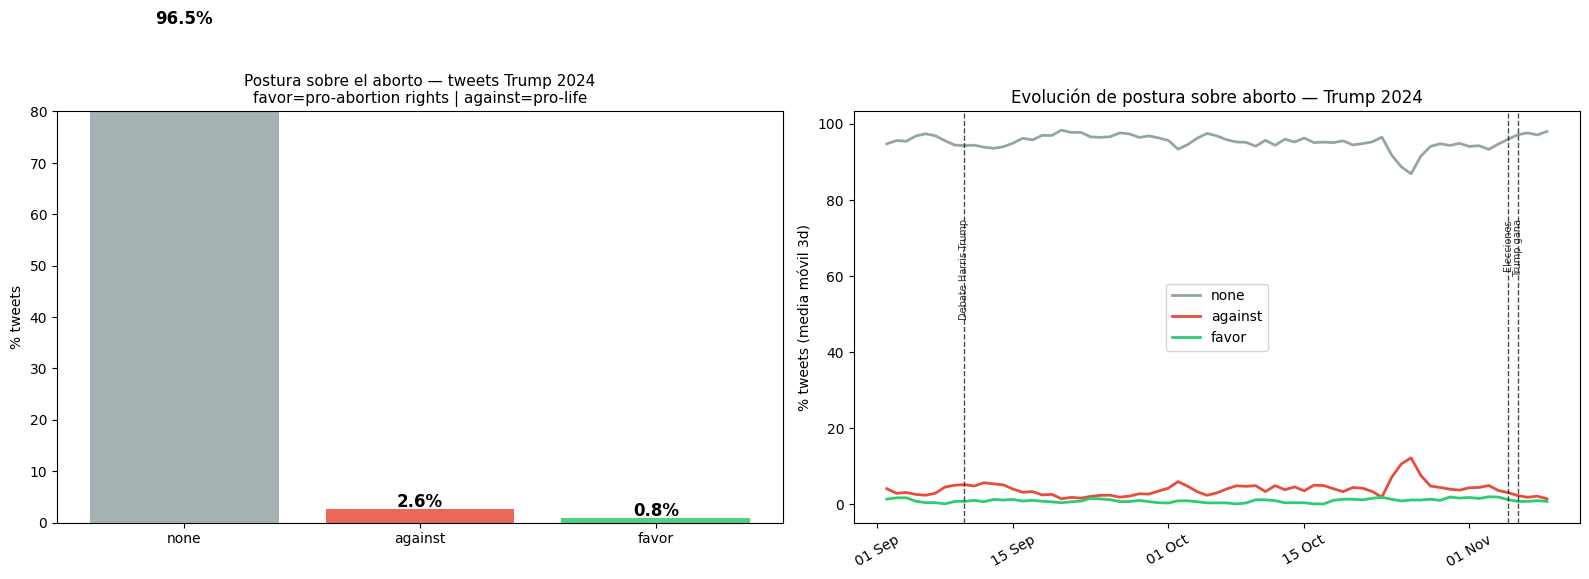


Ejemplos FAVOR (pro-derechos reproductivos):
  [conf=0.98] Donald Trump thinks he should get to make decisions about what you do with your body.

Whether you like it or not.
  [conf=0.98] Women's lives are in danger because of Trump and the MAGA Republicans. They want to control women's bodies and their lives. What will you do to protect our repr
  [conf=0.98] @GeorgeTakei @KellyScaletta If we're going to demonize something, can it be this deranged "your body, my choice" trend? https://t.co/q7cS2j8GpM

Ejemplos AGAINST (pro-vida):
  [conf=0.98] #FightFightFight
I will never shut up until we get our country back, our planet back and the entire medical torture and murder mafia is taken down  and every ch
  [conf=0.98] A VOTE FOR DONALD TRUMP IS A VOTE THAT WILL ENSURE THE DEATH OF THE ANTI-ABORTION MOVEMENT, AND IT WILL PERMANENTLY SHIFT THE CULTURE OF THE REPUBLICAN PARTY IN
  [conf=0.98] @hw_floyd Congratulations 
Welcome to the world Rockwell Montgomery Damare Floyd 
#GodBlessOurChil

In [9]:
if 'abortion' in stance_results.get('trump_2024', {}):
    df_ab = stance_results['trump_2024']['abortion']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Distribución
    ax = axes[0]
    counts = df_ab['stance'].value_counts(normalize=True) * 100
    for stance, color in STANCE_COLORS.items():
        pct = counts.get(stance, 0)
        ax.bar(stance, pct, color=color, alpha=0.85)
        ax.text(stance, pct + 0.5, f'{pct:.1f}%', ha='center', fontsize=12, fontweight='bold')
    ax.set_title('Postura sobre el aborto — tweets Trump 2024\n'
                 'favor=pro-abortion rights | against=pro-life', fontsize=11)
    ax.set_ylabel('% tweets'); ax.set_ylim(0, 80)

    # Timeline
    ax2 = axes[1]
    daily = df_ab.groupby(['date', 'stance']).size().unstack(fill_value=0)
    daily = daily.div(daily.sum(axis=1), axis=0) * 100
    daily.index = pd.to_datetime(daily.index)

    for stance, color in STANCE_COLORS.items():
        if stance in daily.columns:
            rol = daily[stance].rolling(3, center=True).mean()
            ax2.plot(daily.index, rol, color=color, lw=2, label=stance)

    for event_date, label in KEY_EVENTS['trump_2024']:
        ed = pd.Timestamp(event_date)
        ax2.axvline(ed, color='black', ls='--', lw=1, alpha=0.7)
        ax2.text(ed, 75, label, fontsize=7, ha='center', va='top', rotation=90, alpha=0.8)

    ax2.set_title('Evolución de postura sobre aborto — Trump 2024')
    ax2.set_ylabel('% tweets (media móvil 3d)')
    ax2.legend()
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)

    plt.tight_layout()
    plt.savefig('figures/05_stance_abortion_trump2024.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nEjemplos FAVOR (pro-derechos reproductivos):')
    for _, row in df_ab[df_ab['stance']=='favor'].nlargest(3, 'stance_score').iterrows():
        print(f'  [conf={row["stance_score"]:.2f}] {str(row["text"])[:160]}')
    print('\nEjemplos AGAINST (pro-vida):')
    for _, row in df_ab[df_ab['stance']=='against'].nlargest(3, 'stance_score').iterrows():
        print(f'  [conf={row["stance_score"]:.2f}] {str(row["text"])[:160]}')

## 6. España 2023 × Movimiento Feminista

La Ley del Sí es Sí y el debate sobre el movimiento feminista fueron
ejes de división en la campaña del 23J.

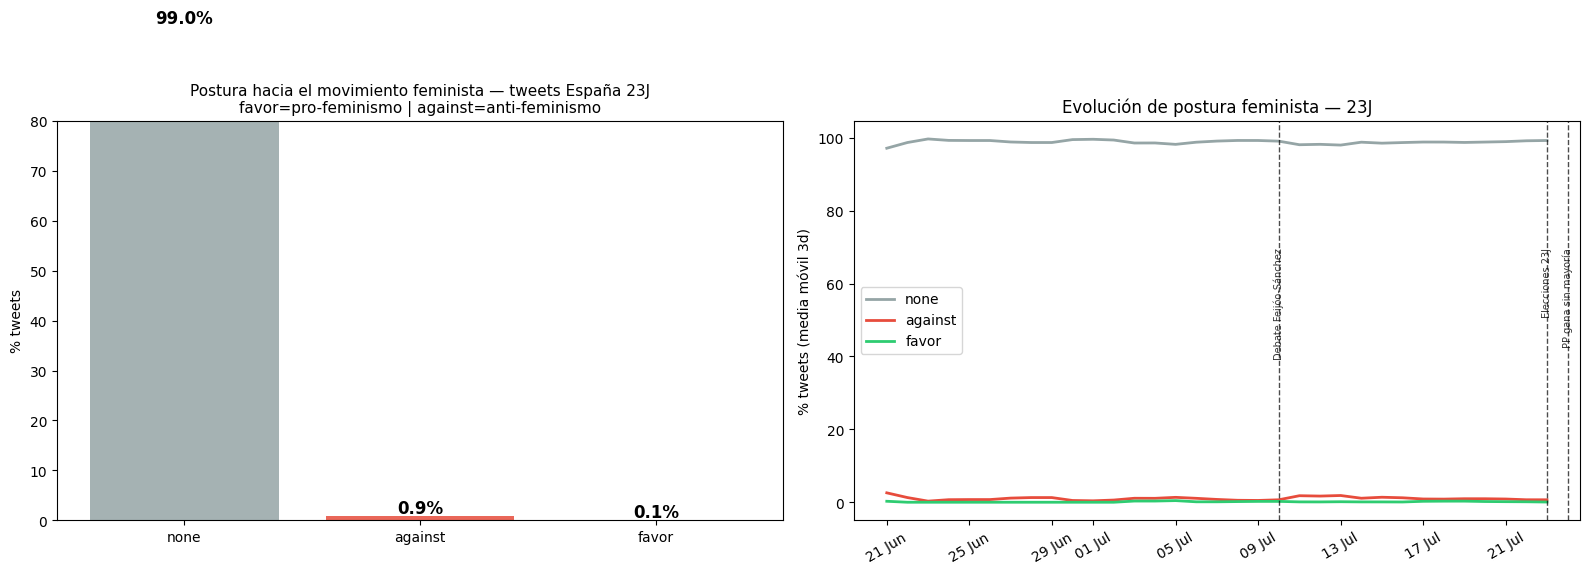


Ejemplos FAVOR feminismo:
  [conf=0.86] 👏 ORGULLOSAS de Irene Montero. 

Ella ha demostrado que SÍ SE PUEDE conquistar una nueva generación de derechos feministas 💜

🎥 @ionebelarra #VotaSumar23J https
  [conf=0.81] Feminismo para cambiarlo todo.
Por una sociedad que nos cuide 💜
#sumar #esporti #votayolanda https://t.co/MVRvpKfCns
  [conf=0.81] Feminismo para cambiarlo todo.
Por una sociedad que nos cuide 💜

#sumar #esporti #votayolanda https://t.co/HpHID2sUg6

Ejemplos AGAINST feminismo:
  [conf=0.97] "izquierda" sentida las FEMINISTAS, no os hemos votado ‼️
#EleccionesGenerales 
#FeminismoNoVotaTraidores 
#LasCuatroDelTaxi 
#FeminismoNoVotaMisoginia 
#VotoNu
  [conf=0.96] Este gilipollas es el de #vox que dijo que las feministas son feas...🤦😏😳😯
  [conf=0.96] @IgualdadLGBT Decir la verdad no es transfobia, te lo dice una anarcofeminista.
"izquierda" sentida. TRAIDORES ‼️
#EleccionesGenerales 
#FeminismoNoVotaTraidore


In [10]:
if 'feminist' in stance_results.get('españa_2023', {}):
    df_fem = stance_results['españa_2023']['feminist']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Distribución
    ax = axes[0]
    counts = df_fem['stance'].value_counts(normalize=True) * 100
    for stance, color in STANCE_COLORS.items():
        pct = counts.get(stance, 0)
        ax.bar(stance, pct, color=color, alpha=0.85)
        ax.text(stance, pct + 0.5, f'{pct:.1f}%', ha='center', fontsize=12, fontweight='bold')
    ax.set_title('Postura hacia el movimiento feminista — tweets España 23J\n'
                 'favor=pro-feminismo | against=anti-feminismo', fontsize=11)
    ax.set_ylabel('% tweets'); ax.set_ylim(0, 80)

    # Timeline
    ax2 = axes[1]
    daily = df_fem.groupby(['date', 'stance']).size().unstack(fill_value=0)
    daily = daily.div(daily.sum(axis=1), axis=0) * 100
    daily.index = pd.to_datetime(daily.index)

    for stance, color in STANCE_COLORS.items():
        if stance in daily.columns:
            rol = daily[stance].rolling(3, center=True).mean()
            ax2.plot(daily.index, rol, color=color, lw=2, label=stance)

    for event_date, label in KEY_EVENTS['españa_2023']:
        ed = pd.Timestamp(event_date)
        ax2.axvline(ed, color='black', ls='--', lw=1, alpha=0.7)
        ax2.text(ed, 70, label, fontsize=7, ha='center', va='top', rotation=90, alpha=0.8)

    ax2.set_title('Evolución de postura feminista — 23J')
    ax2.set_ylabel('% tweets (media móvil 3d)')
    ax2.legend()
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)

    plt.tight_layout()
    plt.savefig('figures/05_stance_feminist_espana2023.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nEjemplos FAVOR feminismo:')
    for _, row in df_fem[df_fem['stance']=='favor'].nlargest(3, 'stance_score').iterrows():
        print(f'  [conf={row["stance_score"]:.2f}] {str(row["text"])[:160]}')
    print('\nEjemplos AGAINST feminismo:')
    for _, row in df_fem[df_fem['stance']=='against'].nlargest(3, 'stance_score').iterrows():
        print(f'  [conf={row["stance_score"]:.2f}] {str(row["text"])[:160]}')

## 7. Análisis cruzado: postura × sentimiento

¿Los tweeteros pro-Hillary tienen sentimiento más positivo o más negativo?
¿Los anti-feministas de España 2023 tweeteaban con más negatividad?

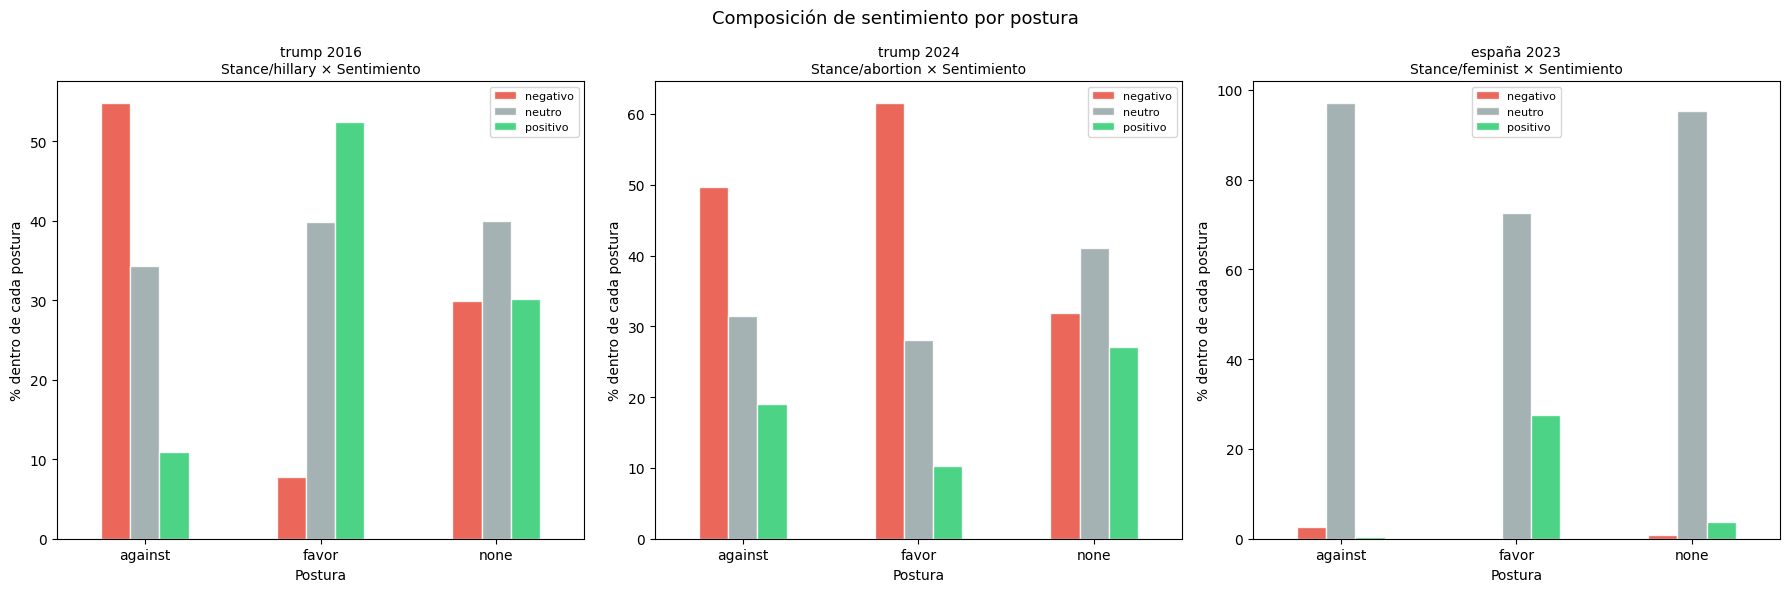

In [11]:
cross_pairs = [
    ('trump_2016',  'hillary'),
    ('trump_2024',  'abortion'),
    ('españa_2023', 'feminist'),
]

valid_pairs = [(c, t) for c, t in cross_pairs
               if c in stance_results and t in stance_results[c]
               and c in sentiment_results]

if valid_pairs:
    n = len(valid_pairs)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 6))
    if n == 1:
        axes = [axes]

    for ax, (campaign, topic) in zip(axes, valid_pairs):
        df_st = stance_results[campaign][topic][['id', 'stance']]
        df_se = sentiment_results[campaign][['id', 'sentiment']]
        df_m  = df_st.merge(df_se, on='id')

        ct = pd.crosstab(df_m['stance'], df_m['sentiment'], normalize='index') * 100
        ct = ct.reindex(columns=['negativo', 'neutro', 'positivo'], fill_value=0)
        ct.plot(kind='bar', ax=ax, color=['#e74c3c', '#95a5a6', '#2ecc71'],
                alpha=0.85, edgecolor='white')
        ax.set_title(f'{campaign.replace("_"," ")}\nStance/{topic} × Sentimiento', fontsize=10)
        ax.set_ylabel('% dentro de cada postura')
        ax.set_xlabel('Postura')
        ax.tick_params(axis='x', rotation=0)
        ax.legend(fontsize=8)

    plt.suptitle('Composición de sentimiento por postura', fontsize=13)
    plt.tight_layout()
    plt.savefig('figures/05_stance_x_sentiment.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Ejecuta primero 03_sentiment_scraped.ipynb para cargar resultados de sentimiento.')

## 8. Resumen comparativo de posturas

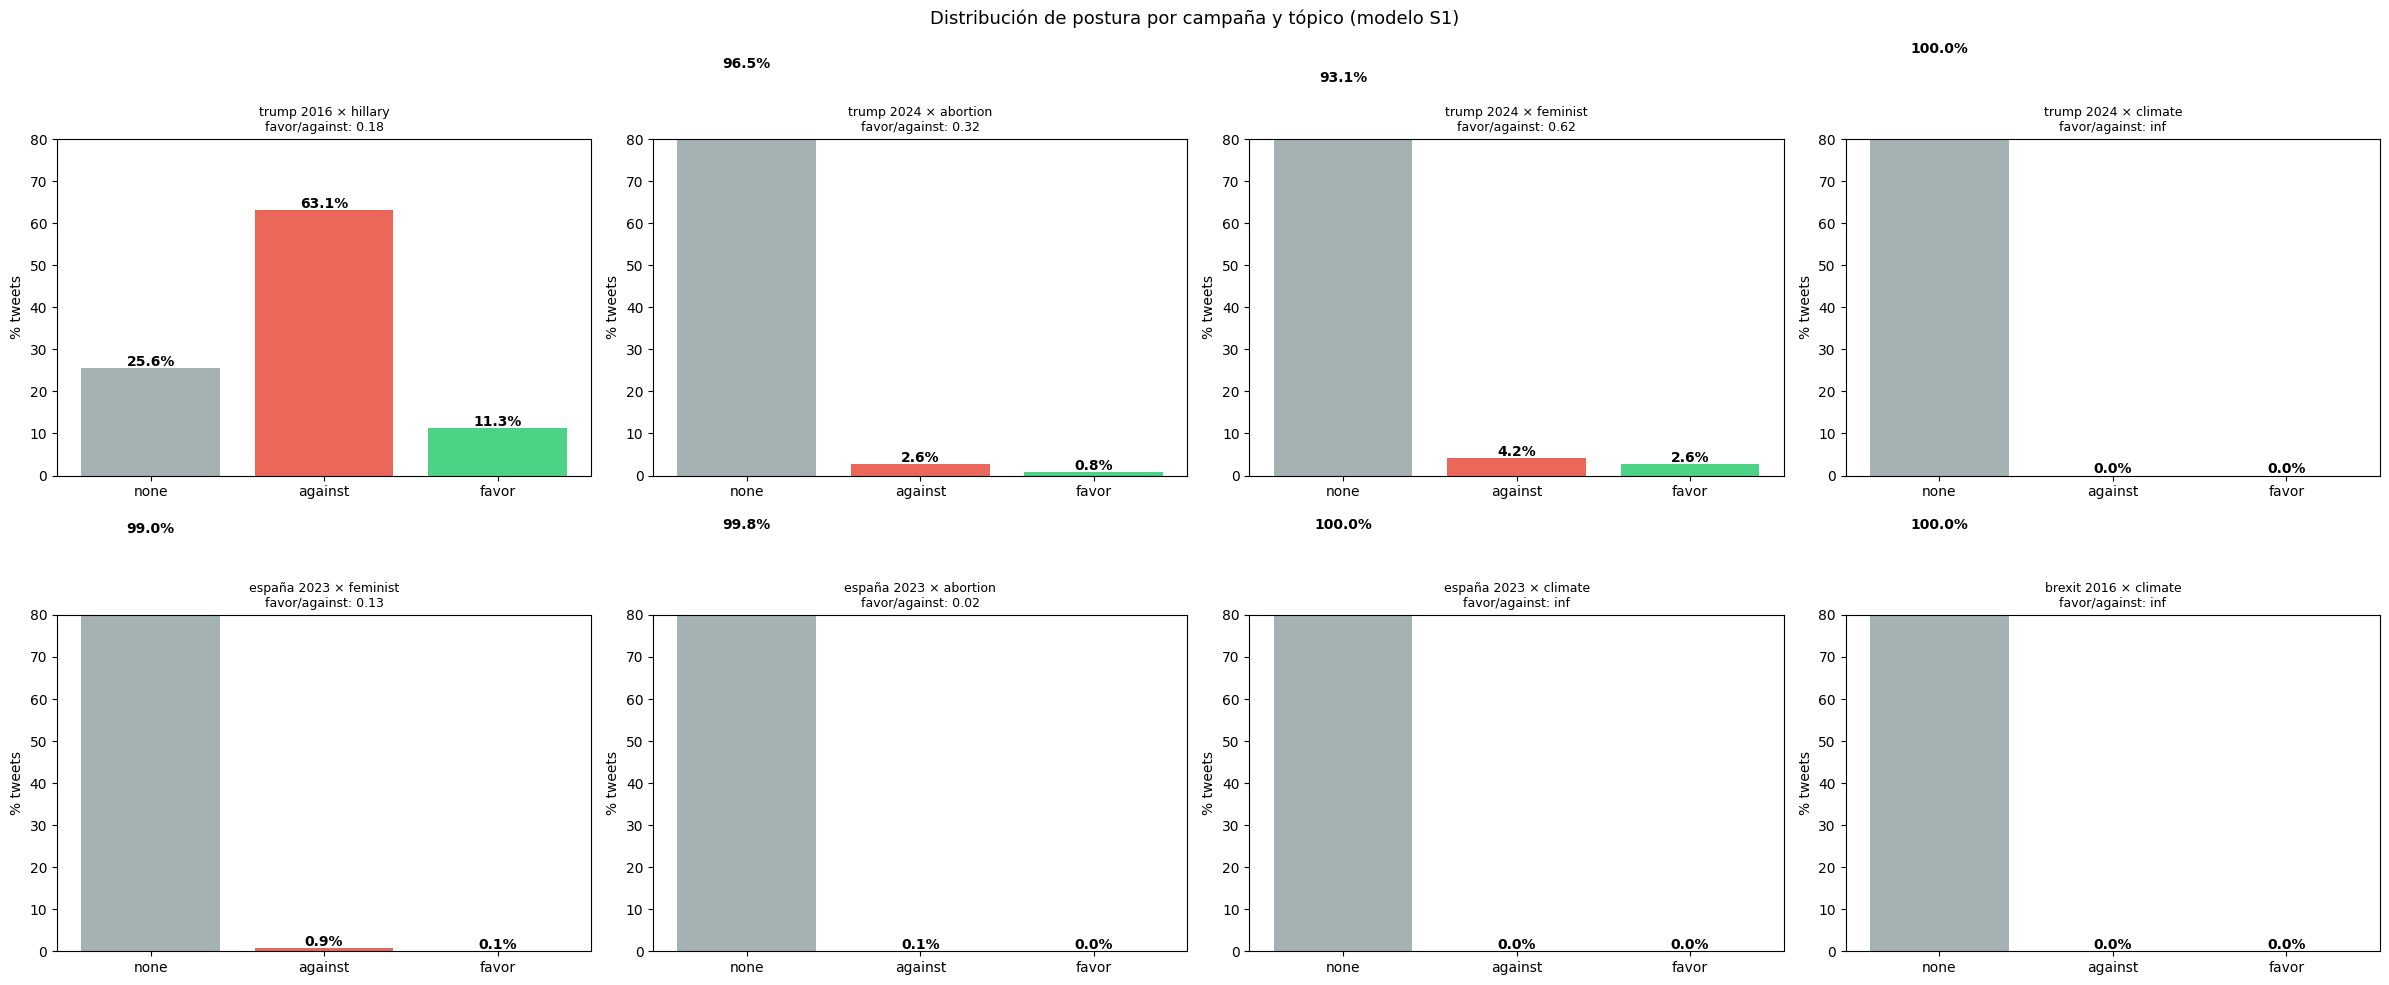


Resumen (favor / against / none %):
  trump_2016/hillary: favor=11.3% against=63.1% none=25.6%
  trump_2024/abortion: favor=0.8% against=2.6% none=96.5%
  trump_2024/feminist: favor=2.6% against=4.2% none=93.1%
  trump_2024/climate: favor=0.0% against=0.0% none=100.0%
  españa_2023/feminist: favor=0.1% against=0.9% none=99.0%
  españa_2023/abortion: favor=0.0% against=0.1% none=99.8%
  españa_2023/climate: favor=0.0% against=0.0% none=100.0%
  brexit_2016/climate: favor=0.0% against=0.0% none=100.0%


In [12]:
all_pairs = [
    ('trump_2016',  'hillary'),
    ('trump_2024',  'abortion'),
    ('trump_2024',  'feminist'),
    ('trump_2024',  'climate'),
    ('españa_2023', 'feminist'),
    ('españa_2023', 'abortion'),
    ('españa_2023', 'climate'),
    ('brexit_2016', 'climate'),
]

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes = axes.flatten()

for ax, (campaign, topic) in zip(axes, all_pairs):
    if campaign not in stance_results or topic not in stance_results[campaign]:
        ax.text(0.5, 0.5, f'{campaign}\n{topic}\n(no disponible)',
                ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
        continue

    df_r   = stance_results[campaign][topic]
    counts = df_r['stance'].value_counts(normalize=True) * 100
    order  = ['none', 'against', 'favor']

    bars = ax.bar(order, [counts.get(s, 0) for s in order],
                  color=[STANCE_COLORS[s] for s in order], alpha=0.85)
    for bar, s in zip(bars, order):
        v = counts.get(s, 0)
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%',
                ha='center', fontsize=10, fontweight='bold')

    favor   = counts.get('favor', 0)
    against = counts.get('against', 0)
    ratio   = favor / against if against > 0 else float('inf')

    ax.set_title(f'{campaign.replace("_"," ")} × {topic}\nfavor/against: {ratio:.2f}', fontsize=9)
    ax.set_ylim(0, 80)
    ax.set_ylabel('% tweets')

plt.suptitle('Distribución de postura por campaña y tópico (modelo S1)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/05_stance_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nResumen (favor / against / none %):')
for campaign, topic in all_pairs:
    if campaign not in stance_results or topic not in stance_results[campaign]:
        continue
    counts = stance_results[campaign][topic]['stance'].value_counts(normalize=True)*100
    print(f'  {campaign}/{topic}: favor={counts.get("favor",0):.1f}% '
          f'against={counts.get("against",0):.1f}% '
          f'none={counts.get("none",0):.1f}%')